# Transfer Learning - VGG16 and ResNet50

is dataset me 5 types ke flowers hain: daisy, dandelion, rose, sunflower, tulip


### step 1 - libraries import

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import os


### step 2 - dataset ka path

flowers-recognition dataset add karne ke baad ye path automatically ban jata hai
isme andar 5 folders hain (daisy, dandelion, rose, sunflower, tulip) - koi alag train/test split nahi he

In [7]:
data_path = "/kaggle/input/datasets/alxmamaev/flowers-recognition/flowers"

print(os.listdir(data_path))


['dandelion', 'daisy', 'sunflower', 'tulip', 'rose']


### step 3 - images ko load karna

is dataset me train/test pehle se divide nahi hai, isliye validation_split khud use kar rahe hain (20% validation ke liye)
rescale se pixel values 0-1 range me aa jati hain

In [8]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(data_path,
                                          target_size=(150,150),
                                          batch_size=32,
                                          class_mode='categorical',
                                          subset='training')

val_data = datagen.flow_from_directory(data_path,
                                        target_size=(150,150),
                                        batch_size=32,
                                        class_mode='categorical',
                                        subset='validation')

print(train_data.class_indices)


Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.
{'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}


### step 4 - kuch images dekhte hain

bas check karne ke liye ke data sahi load hua he

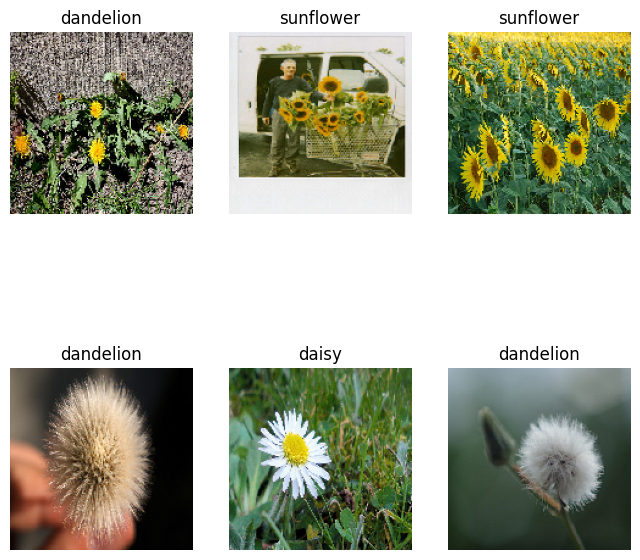

In [9]:
img, label = next(train_data)
class_names = list(train_data.class_indices.keys())

plt.figure(figsize=(8,8))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(img[i])
    plt.title(class_names[label[i].argmax()])
    plt.axis('off')


### step 5 - VGG16 model (transfer learning)

pre-trained model wo model hota he jo pehle se kisi bohot bare dataset (ImageNet - 14 million images) pe train ho chuka hota he
hum uska seekha hua gyaan use karte hain apne chote dataset pe

weights='imagenet' - ImageNet wale pre-trained weights load karte hain
include_top=False - VGG16 ki last classification layer hata dete hain, apni khud ki lagayenge (kyu k humein 5 classes chahiye, 1000 nahi)
base_model.trainable = False - pre-trained layers ko freeze kar dete hain, taake unka seekha hua kharab na ho, sirf nayi layers train hongi

In [10]:
base_model_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(150,150,3))
base_model_vgg.trainable = False

model_vgg = Sequential()
model_vgg.add(base_model_vgg)
model_vgg.add(GlobalAveragePooling2D())
model_vgg.add(Dense(128, activation='relu'))
model_vgg.add(Dropout(0.5))
model_vgg.add(Dense(5, activation='softmax'))

model_vgg.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,997 (56.39 MB)

 Trainable params: 66,309 (259.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

last layer me softmax use kiya he aur 5 neurons rakhe hain kyu k 5 classes hain (sigmoid sirf 2 classes ke liye tha)

### step 6 - VGG16 compile aur training

loss yahan 'categorical_crossentropy' he kyu k multi-class problem he (binary_crossentropy sirf 2 class ke liye hota he)

In [11]:
model_vgg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_vgg = model_vgg.fit(train_data, validation_data=val_data, epochs=10, callbacks=[early_stop])


Epoch 1/10


I0000 00:00:1781960938.391049     132 service.cc:152] XLA service 0x7a030c006c50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781960938.391086     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781960938.391090     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781960938.869776     132 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/109 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.1328 - loss: 1.9456

I0000 00:00:1781960947.517516     132 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


109/109 ━━━━━━━━━━━━━━━━━━━━ 67s 518ms/step - accuracy: 0.4848 - loss: 1.2831 - val_accuracy: 0.6244 - val_loss: 0.9703
Epoch 2/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 15s 136ms/step - accuracy: 0.6540 - loss: 0.9293 - val_accuracy: 0.7221 - val_loss: 0.7963
Epoch 3/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 19s 171ms/step - accuracy: 0.7000 - loss: 0.8255 - val_accuracy: 0.7395 - val_loss: 0.7405
Epoch 4/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 17s 155ms/step - accuracy: 0.7345 - loss: 0.7366 - val_accuracy: 0.7558 - val_loss: 0.6820
Epoch 5/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 16s 142ms/step - accuracy: 0.7405 - loss: 0.7074 - val_accuracy: 0.7651 - val_loss: 0.6519
Epoch 6/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 15s 139ms/step - accuracy: 0.7628 - loss: 0.6595 - val_accuracy: 0.7651 - val_loss: 0.6595
Epoch 7/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 16s 147ms/step - accuracy: 0.7651 - loss: 0.6288 - val_accuracy: 0.7767 - val_loss: 0.6313
Epoch 8/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 16s 147ms/step - accuracy: 0.7810 - loss: 0.6041 - val

### step 7 - ResNet50 model (transfer learning)

bilkul same tareeka jo VGG16 me kiya, bas ab ResNet50 use kar rahe hain
ResNet50 zyada deep network he (50 layers) aur generally VGG se behtar accuracy deta he

In [12]:
base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(150,150,3))
base_model_resnet.trainable = False

model_resnet = Sequential()
model_resnet.add(base_model_resnet)
model_resnet.add(GlobalAveragePooling2D())
model_resnet.add(Dense(128, activation='relu'))
model_resnet.add(Dropout(0.5))
model_resnet.add(Dense(5, activation='softmax'))

model_resnet.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### step 8 - ResNet50 compile aur training

In [13]:
model_resnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop2 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_resnet = model_resnet.fit(train_data, validation_data=val_data, epochs=10, callbacks=[early_stop2])


Epoch 1/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 35s 216ms/step - accuracy: 0.2586 - loss: 1.6095 - val_accuracy: 0.3384 - val_loss: 1.5356
Epoch 2/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - accuracy: 0.3141 - loss: 1.5397 - val_accuracy: 0.3488 - val_loss: 1.5216
Epoch 3/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - accuracy: 0.3318 - loss: 1.5215 - val_accuracy: 0.3535 - val_loss: 1.4903
Epoch 4/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.3251 - loss: 1.5175 - val_accuracy: 0.3547 - val_loss: 1.4922
Epoch 5/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - accuracy: 0.3474 - loss: 1.5076 - val_accuracy: 0.3558 - val_loss: 1.4799
Epoch 6/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - accuracy: 0.3465 - loss: 1.5020 - val_accuracy: 0.3512 - val_loss: 1.4861
Epoch 7/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - accuracy: 0.3410 - loss: 1.5043 - val_accuracy: 0.3651 - val_loss: 1.4907
Epoch 8/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - accuracy: 0.3373 - loss: 1.

### step 9 - dono models ka comparison (graph)

dono ki validation accuracy ek hi graph pe dekhte hain, taake pata chale konsa better he is dataset ke liye

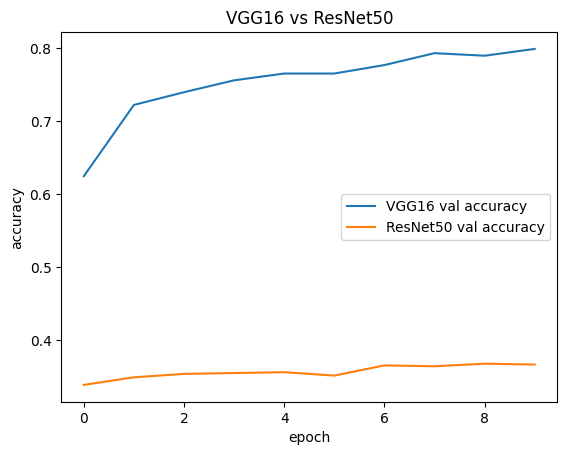

In [14]:
plt.plot(history_vgg.history['val_accuracy'], label='VGG16 val accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='ResNet50 val accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('VGG16 vs ResNet50')
plt.legend()
plt.show()


### step 10 - ek image pe test karna

dataset se koi bhi ek image utha k dono models se predict karwate hain

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 651ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


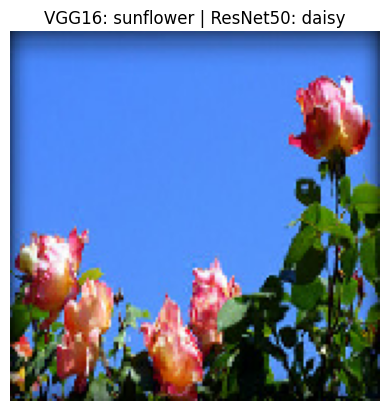

In [15]:
from tensorflow.keras.preprocessing import image
import numpy as np

# yahan apni image ka naam/path daal dein, kisi bhi folder me se koi bhi
test_img_path = data_path + "/rose/" + os.listdir(data_path + "/rose")[0]

img = image.load_img(test_img_path, target_size=(150,150))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

pred_vgg = model_vgg.predict(img_array)
pred_resnet = model_resnet.predict(img_array)

plt.imshow(img)
plt.axis('off')
plt.title("VGG16: " + class_names[pred_vgg.argmax()] + " | ResNet50: " + class_names[pred_resnet.argmax()])
plt.show()
